# Mask → YOLO Segmentation Labels

將 `all_data_nodule_normal_cut_seg/masks/` 中的灰階 mask 轉換為 YOLO seg 格式的 `labels/`。

**YOLO seg label 格式**（每行一個物件）：
```
<class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
```
其中座標為相對於圖片寬高的正規化值（0~1）。

**Mask 數值對應類別**（依實際資料調整）：
- `1` 或 `255` → class 0: `nodule`
- `2` → class 1: `maybe_nodule`
- `0` → 背景（忽略）

In [2]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
# ── 路徑設定 ──────────────────────────────────────────────
# notebook 位於 yolo_data/ 資料夾內，working dir = yolo_data/
BASE_DIR  = Path("all_data_nodule_normal_cut_seg")
MASK_DIR  = BASE_DIR / "masks"
LABEL_DIR = BASE_DIR / "labels"
IMG_DIR   = BASE_DIR / "images"

LABEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"masks  : {MASK_DIR}  ({len(list(MASK_DIR.glob('*.png')))} files)")
print(f"images : {IMG_DIR}   ({len(list(IMG_DIR.glob('*.png')))} files)")
print(f"labels : {LABEL_DIR} (output)")

## 1. 先檢查 mask 的數值分佈

In [9]:
# 取前 200 個 mask 統計唯一值
from collections import Counter

all_unique = Counter()
sample_masks = sorted(MASK_DIR.glob("*.png"))[:]

for p in tqdm(sample_masks):
    mask = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    for v in np.unique(mask):
        all_unique[int(v)] += 1
    if int(v) > 2:
        print(p)

print("Mask 像素唯一值 → 出現在幾張圖中：")
for k, cnt in sorted(all_unique.items()):
    print(f"  value={k:3d}  in {cnt} masks")

100%|██████████| 20645/20645 [00:30<00:00, 673.11it/s] 

Mask 像素唯一值 → 出現在幾張圖中：
  value=  0  in 20645 masks
  value=  1  in 15833 masks
  value=  2  in 2236 masks


In [10]:
# ── Mask 數值 → YOLO class id 對應表 ──────────────────────
# 請依上方統計結果確認後再執行後續步驟
#
# 預設規則：
#   255 或 1  → class 0 (nodule)
#   2         → class 1 (maybe_nodule)
#   0         → background (skip)

MASK_VALUE_TO_CLASS = {
    255: 0,   # nodule
    1:   0,   # nodule (有些工具存 1 而非 255)
    2:   1,   # maybe_nodule
}

# 輪廓近似方式：CHAIN_APPROX_SIMPLE 較精簡；NONE 保留全部像素
CONTOUR_APPROX = cv2.CHAIN_APPROX_SIMPLE

# 過濾太小的輪廓（像素面積，避免雜訊）
MIN_AREA_PX = 10

# 輪廓多邊形點數上限（-1 = 不限；設較小值可壓縮 label 大小）
MAX_POLYGON_POINTS = -1   # -1 表示不壓縮

print("Class mapping:", MASK_VALUE_TO_CLASS)

Class mapping: {255: 0, 1: 0, 2: 1}


## 2. 視覺化幾張樣本（確認 mask 正確）

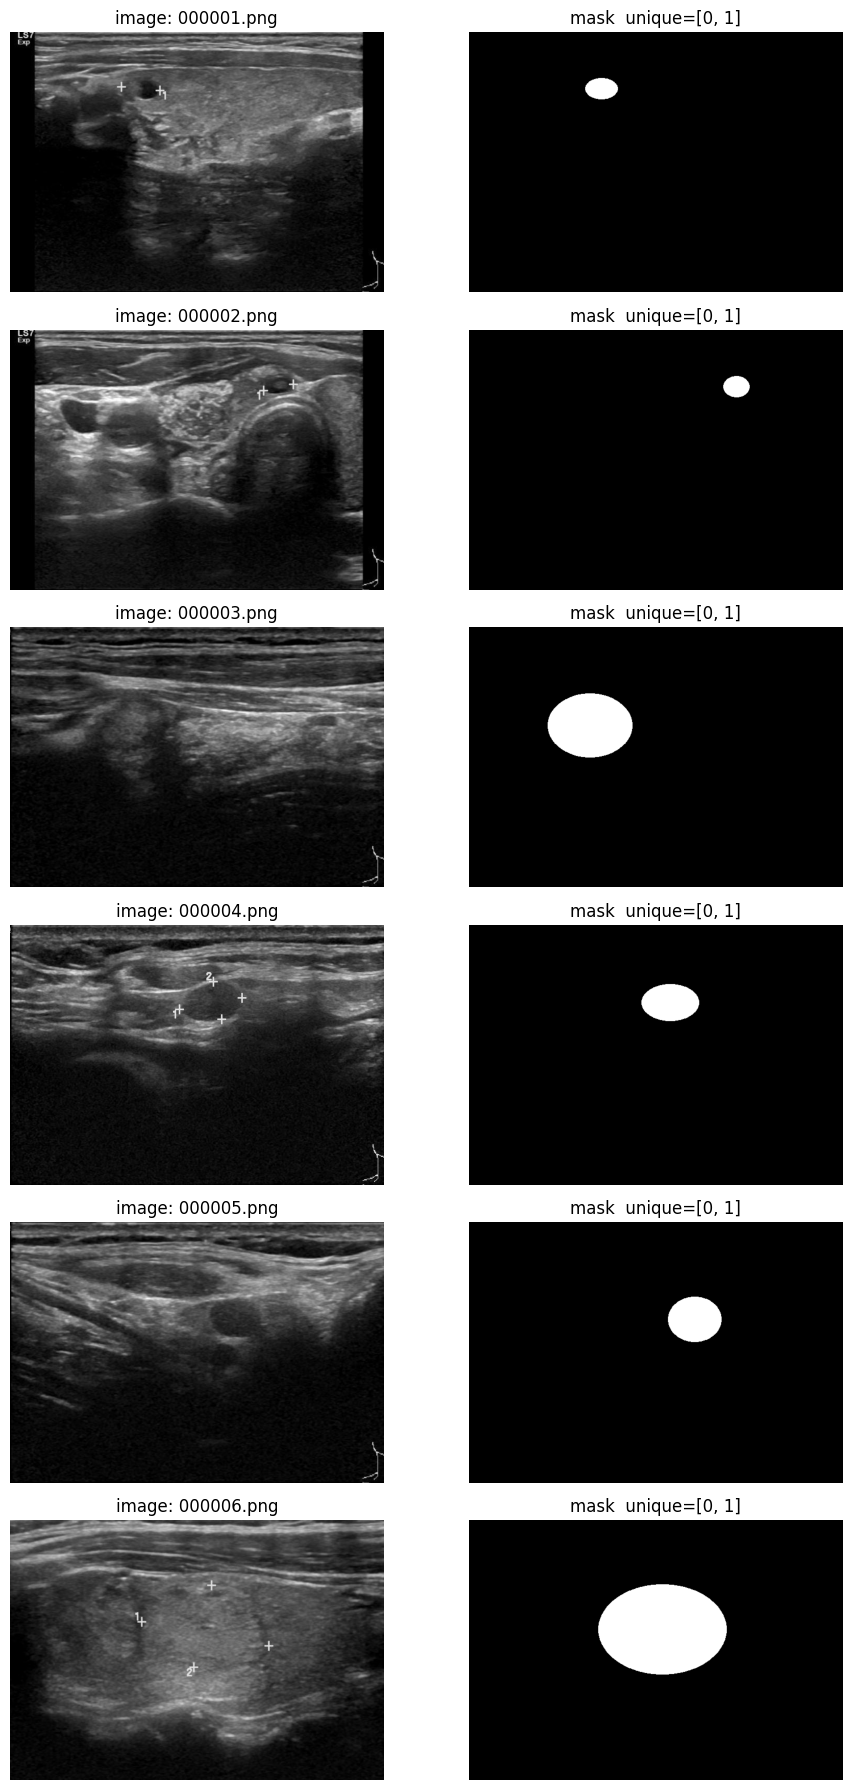

In [11]:
SHOW_N = 6
samples = sorted(MASK_DIR.glob("*.png"))[:SHOW_N]

fig, axes = plt.subplots(SHOW_N, 2, figsize=(10, SHOW_N * 3))
for i, mp in enumerate(samples):
    img  = cv2.imread(str(IMG_DIR / mp.name))
    mask = cv2.imread(str(mp), cv2.IMREAD_UNCHANGED)

    axes[i, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.zeros((10,10,3), dtype=np.uint8))
    axes[i, 0].set_title(f"image: {mp.name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"mask  unique={np.unique(mask).tolist()}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 3. 轉換函式

In [12]:
def mask_to_yolo_seg_lines(mask: np.ndarray,
                            mask_value_to_class: dict,
                            min_area_px: int = 10,
                            max_pts: int = -1) -> list[str]:
    """
    將單張灰階 mask 轉為 YOLO seg label 文字行列表。

    Returns
    -------
    list[str]  每個物件一行，格式：
        "class_id x1 y1 x2 y2 ... xn yn"
    """
    h, w = mask.shape[:2]
    lines = []

    for pixel_val, class_id in mask_value_to_class.items():
        # 取出該類別的二值 mask
        binary = np.where(mask == pixel_val, np.uint8(255), np.uint8(0))
        if binary.max() == 0:
            continue  # 這張圖沒有此類別

        # 找輪廓（外輪廓）
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, CONTOUR_APPROX)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < min_area_px:
                continue

            # 壓縮點數（可選）
            if max_pts > 0 and len(cnt) > max_pts:
                epsilon = cv2.arcLength(cnt, True) * 0.01
                cnt = cv2.approxPolyDP(cnt, epsilon, True)
                # 若近似後點數仍過多，逐漸增大 epsilon
                while len(cnt) > max_pts:
                    epsilon *= 1.5
                    cnt = cv2.approxPolyDP(cnt, epsilon, True)

            # 至少需要 3 個點
            pts = cnt.reshape(-1, 2)
            if len(pts) < 3:
                continue

            # 正規化到 [0, 1]
            norm_pts = pts.astype(np.float32)
            norm_pts[:, 0] /= w
            norm_pts[:, 1] /= h
            norm_pts = np.clip(norm_pts, 0.0, 1.0)

            # 組成一行字串
            coords_str = " ".join(f"{x:.6f} {y:.6f}" for x, y in norm_pts)
            lines.append(f"{class_id} {coords_str}")

    return lines

## 4. 批次轉換所有 mask → labels

In [13]:
mask_paths = sorted(MASK_DIR.glob("*.png"))
print(f"共 {len(mask_paths)} 個 mask，開始轉換...")

stats = {"ok": 0, "empty": 0, "no_mask": 0}

for mp in tqdm(mask_paths, desc="Converting"):
    mask = cv2.imread(str(mp), cv2.IMREAD_UNCHANGED)
    if mask is None:
        stats["no_mask"] += 1
        continue

    # 若 mask 是多通道（例如 RGB），取第一個 channel
    if mask.ndim == 3:
        mask = mask[:, :, 0]

    lines = mask_to_yolo_seg_lines(
        mask,
        MASK_VALUE_TO_CLASS,
        min_area_px=MIN_AREA_PX,
        max_pts=MAX_POLYGON_POINTS,
    )

    label_path = LABEL_DIR / (mp.stem + ".txt")
    with open(label_path, "w") as f:
        f.write("\n".join(lines))

    if lines:
        stats["ok"] += 1
    else:
        stats["empty"] += 1

print("\n完成！")
print(f"  有 label 的圖  : {stats['ok']}")
print(f"  空 label（背景）: {stats['empty']}")
print(f"  讀取失敗       : {stats['no_mask']}")
print(f"\nlabels 資料夾   : {LABEL_DIR}")

共 20645 個 mask，開始轉換...


Converting: 100%|██████████| 20645/20645 [00:19<00:00, 1062.35it/s]


完成！
  有 label 的圖  : 15836
  空 label（背景）: 4809
  讀取失敗       : 0

labels 資料夾   : all_data_nodule_normal_cut_seg/labels


## 5. 視覺化驗證：把 label 畫回圖片

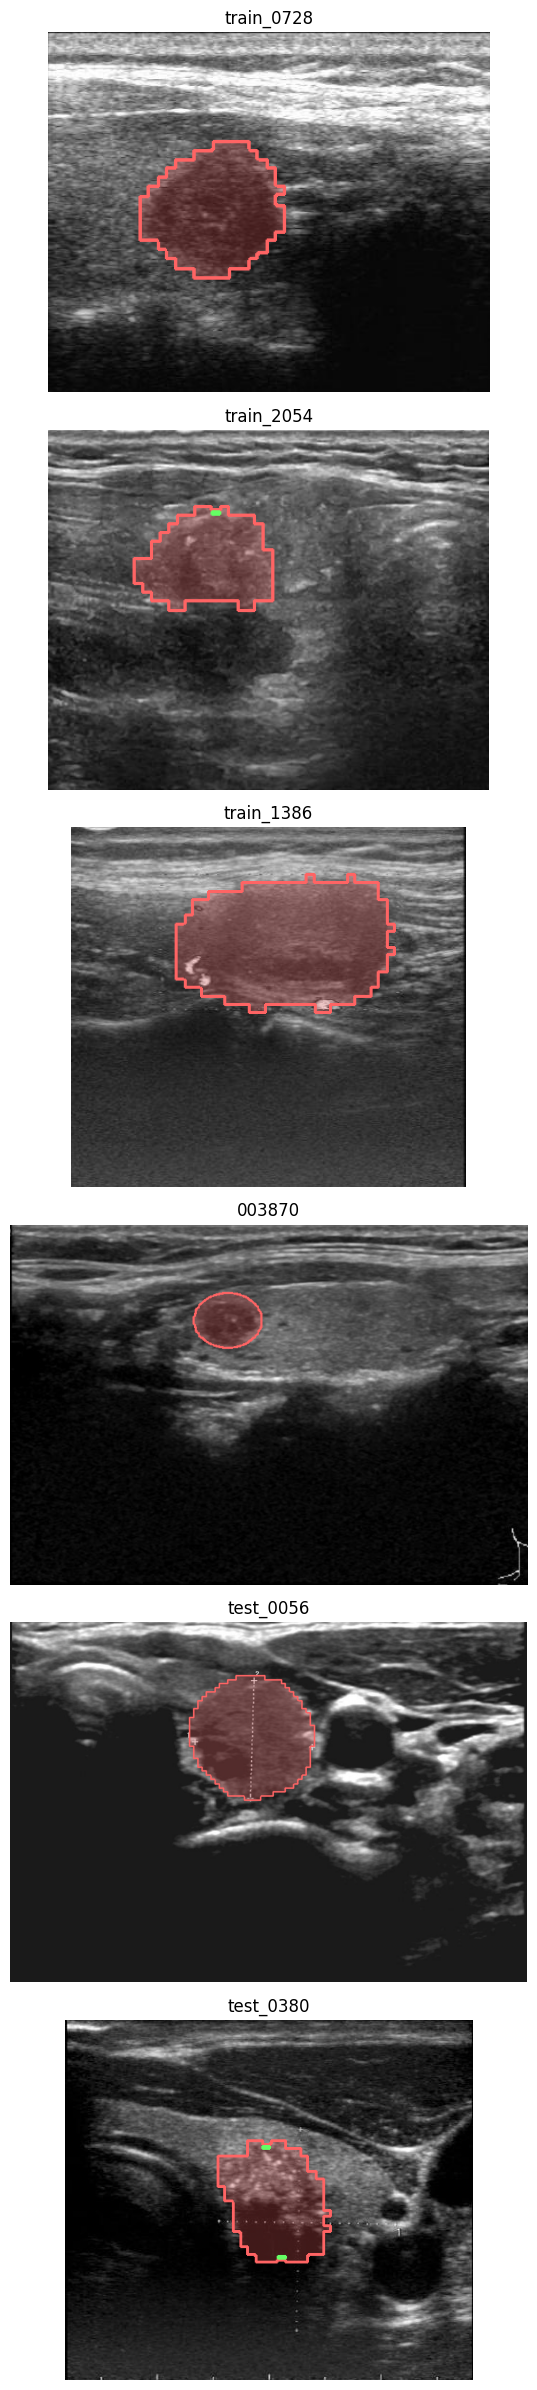

In [14]:
CLASS_COLORS = {
    0: (255, 100, 100),   # nodule       → 紅
    1: (100, 255, 100),   # maybe_nodule → 綠
}

def draw_yolo_seg(img_bgr: np.ndarray, label_path: Path) -> np.ndarray:
    """將 YOLO seg label 畫在圖片上，回傳 RGB。"""
    h, w = img_bgr.shape[:2]
    vis = img_bgr.copy()

    if not label_path.exists():
        return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            pts = np.array([[coords[i]*w, coords[i+1]*h]
                            for i in range(0, len(coords), 2)], dtype=np.int32)
            color = CLASS_COLORS.get(class_id, (200, 200, 200))
            cv2.polylines(vis, [pts], isClosed=True, color=color[::-1], thickness=2)
            overlay = vis.copy()
            cv2.fillPoly(overlay, [pts], color=color[::-1])
            vis = cv2.addWeighted(overlay, 0.25, vis, 0.75, 0)

    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)


# ── 隨機抽 6 張有 label 的圖顯示 ──
import random

label_files = [p for p in sorted(LABEL_DIR.glob("*.txt")) if p.stat().st_size > 0]
samples = random.sample(label_files, min(6, len(label_files)))

fig, axes = plt.subplots(len(samples), 1, figsize=(12, len(samples) * 4))
if len(samples) == 1:
    axes = [axes]

for ax, lp in zip(axes, samples):
    img_path = IMG_DIR / (lp.stem + ".png")
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    vis = draw_yolo_seg(img, lp)
    ax.imshow(vis)
    ax.set_title(lp.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. 更新 data.yaml（加上 labels 路徑）

In [15]:
import yaml

yaml_path = BASE_DIR / "data.yaml"
with open(yaml_path) as f:
    cfg = yaml.safe_load(f)

# 確認 path 指向 seg 資料夾
cfg["path"] = str(BASE_DIR.resolve())

print("目前 data.yaml 內容：")
for k, v in cfg.items():
    print(f"  {k}: {v}")

print("\n⚠️  請確認 train/val txt 中的路徑是否指向 seg 資料夾的 images/，")
print("   若路徑指向 all_data_nodule_normal_cut，需另行建立對應的 txt 檔。")

目前 data.yaml 內容：
  path: /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_data/all_data_nodule_normal_cut_seg
  train: train_v5.txt
  val: val_v5_CG.txt
  names: {0: 'nodule', 1: 'maybe_nodule'}
  nc: 2

⚠️  請確認 train/val txt 中的路徑是否指向 seg 資料夾的 images/，
   若路徑指向 all_data_nodule_normal_cut，需另行建立對應的 txt 檔。


## 7. 產生符合 seg 資料夾的 train / val txt（可選）

原本的 `train_v5.txt` 路徑指向 `all_data_nodule_normal_cut/images/`，
若要讓 YOLO 找到 `all_data_nodule_normal_cut_seg/` 的 images，
執行以下 cell 重新產生 txt 檔。

In [20]:
# 原始 txt 中路徑格式：yolo_data/all_data_nodule_normal_cut/images/xxx.png
# notebook 在 yolo_data/ 內，所以新路徑只需：all_data_nodule_normal_cut_seg/images/xxx.png

def remap_txt(src_txt: Path, dst_txt: Path):
    """將 src_txt 中的 stem 對應到 seg images/，過濾不存在的檔案。"""
    lines_out = []
    with open(src_txt) as f:
        for line in f:
            stem = Path(line.strip()).stem
            img_candidate = BASE_DIR / "images" / (stem + ".png")
            if img_candidate.exists():
                lines_out.append(str("yolo_data" / img_candidate))
    with open(dst_txt, "w") as f:
        f.write("\n".join(lines_out))
    print(f"  {dst_txt.name}: {len(lines_out)} 筆")

print("建立 seg 用的 train/val txt...")
remap_txt(BASE_DIR / "train_v5.txt", BASE_DIR / "train_v5.txt")
remap_txt(BASE_DIR / "val_v5_CG.txt", BASE_DIR / "val_v5_CG.txt")

建立 seg 用的 train/val txt...
  train_v5.txt: 16167 筆
  val_v5_CG.txt: 2364 筆


In [8]:
"all_yolo_data" / BASE_DIR

PosixPath('all_yolo_data/all_data_nodule_normal_cut_seg')

<cell_type>markdown</cell_type>## 8. 訓練指令範例

```bash
# YOLO v8 seg（在 yolo_data/ 資料夾內執行）
yolo task=segment mode=train \
     model=yolov8n-seg.pt \
     data=all_data_nodule_normal_cut_seg/data_seg.yaml \
     epochs=100 imgsz=640 batch=16

# 或使用 Python API
# from ultralytics import YOLO
# model = YOLO("yolov8n-seg.pt")
# model.train(data="all_data_nodule_normal_cut_seg/data_seg.yaml",
#             epochs=100, imgsz=640, batch=16)
```

> **注意**：YOLO seg 會自動從 `images/` 路徑推斷 `labels/` 路徑（替換路徑中的 `images` → `labels`），
> 因此 label txt 的命名必須與 image 檔名相同、副檔名改為 `.txt`。